In [ ]:
!pip install -q monai

from monai.apps import download_and_extract

download_and_extract(
    "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar",
    "/content/data",
    "/content/data"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.6 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


2026-04-22 04:30:22,549 - WARNING - filepath=/content/data, which missing file extension. Auto-appending extension to: /content/data.tar


data.tar: 7.09GB [03:28, 36.4MB/s]                            

2026-04-22 04:33:51,517 - INFO - Downloaded: /content/data.tar
2026-04-22 04:33:51,518 - INFO - Expected md5 is None, skip md5 check for file /content/data.tar.
2026-04-22 04:33:51,520 - INFO - Writing into directory: /content/data.


In [ ]:
import os, numpy as np, nibabel as nib
from PIL import Image
import random, shutil

images_path = "/content/data/Task01_BrainTumour/imagesTr"
labels_path = "/content/data/Task01_BrainTumour/labelsTr"
output_path = "/content/yolo_dataset"

# clean folder
if os.path.exists(output_path):
    shutil.rmtree(output_path)

for split in ["train", "val"]:
    os.makedirs(f"{output_path}/images/{split}", exist_ok=True)
    os.makedirs(f"{output_path}/labels/{split}", exist_ok=True)

files = [f for f in os.listdir(images_path) if f.endswith(".nii.gz") and not f.startswith("._")]

random.shuffle(files)
split = int(0.8 * len(files))
train_files = files[:split]
val_files = files[split:]

count = 0

def process(files, split):
    global count
    for f in files:
        img = nib.load(os.path.join(images_path, f)).get_fdata()
        lbl = nib.load(os.path.join(labels_path, f)).get_fdata()

        for i in range(20, img.shape[2]-20):
            img_slice = img[:, :, i, 3]
            mask = lbl[:, :, i]

            if np.sum(mask) == 0:
                continue

            img_slice = (img_slice - img_slice.min())/(img_slice.max()-img_slice.min()+1e-8)
            img_slice = (img_slice*255).astype("uint8")
            img_slice = np.stack([img_slice]*3, axis=-1)

            coords = np.where(mask > 0)
            x_min, x_max = coords[1].min(), coords[1].max()
            y_min, y_max = coords[0].min(), coords[0].max()

            # tighten bbox
            x_min += 2; y_min += 2
            x_max -= 2; y_max -= 2

            if x_min >= x_max or y_min >= y_max:
                continue

            if (x_max-x_min)<10 or (y_max-y_min)<10:
                continue

            Image.fromarray(img_slice).save(f"{output_path}/images/{split}/{count}.png")

            h, w = mask.shape
            xc = ((x_min+x_max)/2)/w
            yc = ((y_min+y_max)/2)/h
            bw = (x_max-x_min)/w
            bh = (y_max-y_min)/h

            with open(f"{output_path}/labels/{split}/{count}.txt","w") as ftxt:
                ftxt.write(f"0 {xc} {yc} {bw} {bh}")

            count += 1

process(train_files, "train")
process(val_files, "val")

print("Dataset created:", count)

Dataset created: 30137


In [ ]:
import os

print("Train:", len(os.listdir("/content/yolo_dataset/images/train")))
print("Val:", len(os.listdir("/content/yolo_dataset/images/val")))

Train: 24435
Val: 5702


In [ ]:
yaml = """
path: /content/yolo_dataset
train: images/train
val: images/val

nc: 1
names: ['tumor']
"""

with open("/content/yolo_dataset.yaml", "w") as f:
    f.write(yaml)

print("YAML ready")

YAML ready


In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
print("Ultralytics ready")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics ready


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/yolo_dataset.yaml",
    epochs=20,
    imgsz=256,
    batch=32,
    patience=6,
    project="/content/runs",
    name="final_run"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=6, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e29927cec0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/final_run/weights/best.pt")

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 625.9±308.2 MB/s, size: 22.2 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 5702 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5702/5702 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 357/357 11.2it/s 31.8s
                   all       5702       5702      0.879      0.789      0.834       0.52
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /usr/local/lib/python3.12/dist-packages/tests/tmp/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e295133e60>
curves: [

In [ ]:
results_dict = {
    "precision": float(metrics.box.p),
    "recall": float(metrics.box.r),
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map)
}

print(results_dict)

{'precision': 0.879265641572184, 'recall': 0.7886706418800421, 'mAP50': 0.8343379134370463, 'mAP50_95': 0.5200955553031097}


/tmp/ipykernel_2672/3696815193.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "precision": float(metrics.box.p),
/tmp/ipykernel_2672/3696815193.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "recall": float(metrics.box.r),


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/final_run/weights/best.pt")
model.val()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 586.7±288.0 MB/s, size: 15.9 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 5702 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5702/5702 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 357/357 10.8it/s 33.0s
                   all       5702       5702      0.879      0.789      0.834       0.52
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /usr/local/lib/python3.12/dist-packages/tests/tmp/runs/detect/val-2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e295fe6690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
!find /content -name best.pt

/content/runs/final_run/weights/best.pt



image 1/1 /content/yolo_dataset/images/val/27401.png: 256x256 2 tumors, 12.3ms
Speed: 1.3ms preprocess, 12.3ms inference, 2.4ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/30133.png: 256x256 1 tumor, 14.2ms
Speed: 1.9ms preprocess, 14.2ms inference, 2.8ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/26535.png: 256x256 1 tumor, 7.5ms
Speed: 0.9ms preprocess, 7.5ms inference, 1.8ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/yolo_dataset/images/val/28089.png: 256x256 1 tumor, 7.4ms
Speed: 1.2ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 256)


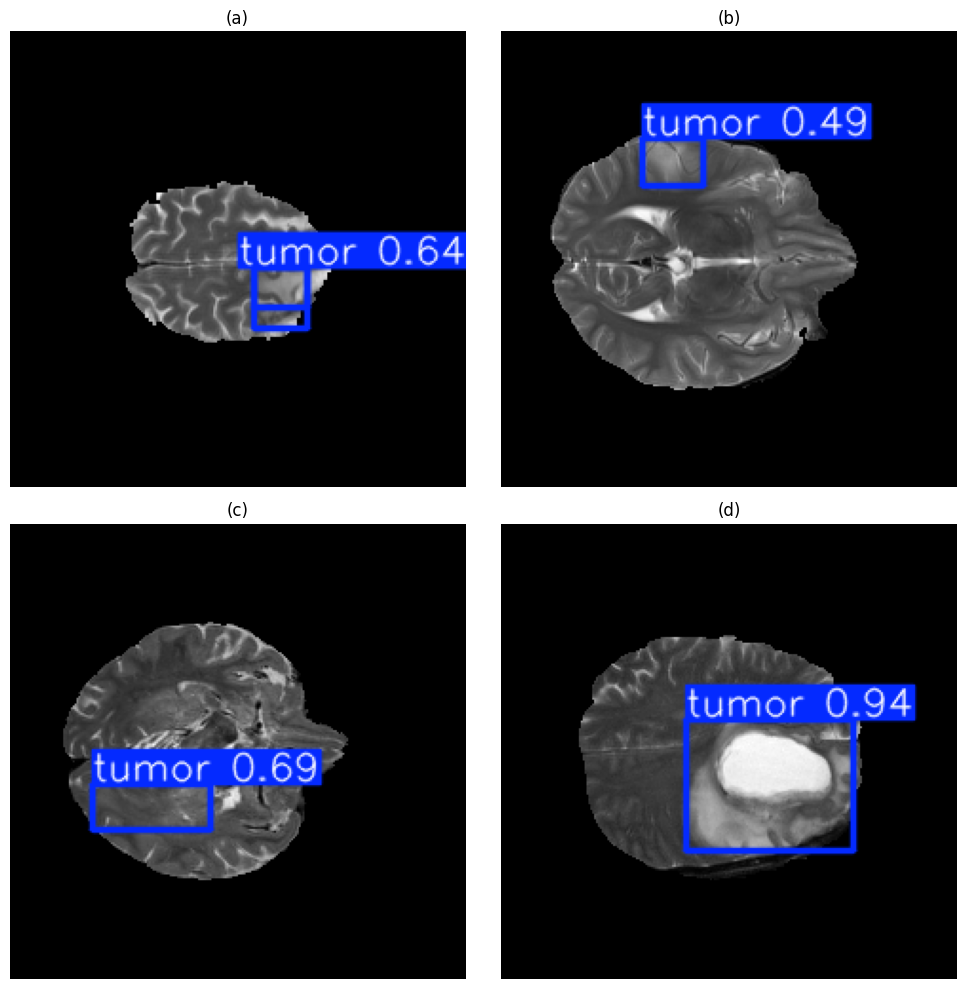

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob

images = glob.glob("/content/yolo_dataset/images/val/*.png")[:4]

plt.figure(figsize=(10,10))
labels = ['(a)', '(b)', '(c)', '(d)']

for i, img_path in enumerate(images):
    results = model(img_path)
    img = results[0].plot()

    plt.subplot(2,2,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.savefig("/content/figure_exp2.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("/content/figure_exp2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

shutil.copy(
    "/content/runs/final_run/weights/best.pt",
    "/content/drive/MyDrive/final_model.pt"
)

print("Model saved successfully!")

Mounted at /content/drive
Model saved successfully!


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/final_model.pt"))

True


In [ ]:
import json

results = {
    "precision": 0.879,
    "recall": 0.789,
    "mAP50": 0.834,
    "mAP50_95": 0.520
}

with open("/content/drive/MyDrive/final_results.json", "w") as f:
    json.dump(results, f)

print("Results saved!")

Results saved!


In [ ]:
#comparison with base model

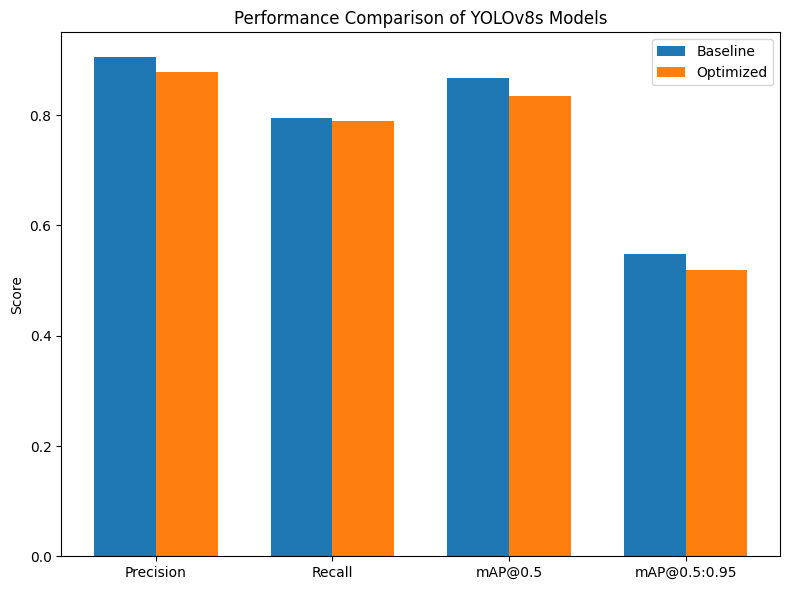

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]

baseline = [0.905, 0.795, 0.867, 0.548]
optimized = [0.879, 0.789, 0.834, 0.520]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, baseline, width, label="Baseline")
plt.bar(x + width/2, optimized, width, label="Optimized")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison of YOLOv8s Models")
plt.legend()

plt.tight_layout()
plt.savefig("/content/figure3_comparison.png", dpi=300)
plt.show()

In [2]:
from google.colab import files
files.download("/content/figure3_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>